**Inclass : Time Series and Forecasting**
    
- Part of Comprehensive Data Science and Machine Learning
- Course Length: 9 Hours
- Last Updated: October 2025

---

- Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

## Training Objectives

- **Working with Time Series**
  - Data Preprocessing
  - Visualization: Time Series
- **Modeling using `prophet`**
  - Baseline Model
  - Trend Component
  - Seasonality Component
- **Forecasting Evaluation**
  - Train-Test Split
  - Evaluation Metrics: MAPE
- **Hyperparameter Tuning**
  - Custom Seasonality
  - Holiday Effects

In [1]:
import pandas as pd

# pandas output display setup
pd.options.display.float_format = '{:,.2f}'.format

# menghilangkan warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from prophet import Prophet

# 📈 Time Series and Forecasting 📈

- **Time Series** merupakan data yang berhubungan dengan waktu yang memiliki interval waktu yang sama (memiliki periode pengambilan data yang sama)
contoh: 
    - Data curah hujan 
    - Harga saham 
    - Permintaan barang setiap bulan 
    - Data pendapatan bulanan
    
- **Forecasting** merupakan proses prediksi untuk data time series berdasarkan pola data historisnya

**Time series forecasting** merupakan komponen penting dalam analisis data, dan menjadi semakin penting dalam beberapa tahun terakhir karena bisnis mengandalkan data untuk mengambil keputusan yang tepat. Kemampuan untuk memprediksi tren masa depan sangat penting bagi berbagai industri, termasuk keuangan, layanan kesehatan, dan e-commerce.
    

### 💰 Study Case : Prediksi Harga Minyak 💰

Pergerakan harga minyak mentah dipengaruhi oleh banyak faktor yang beragam (misalnya kondisi geopolitik, supply-demand global, keputusan OPEC, nilai tukar dolar, kondisi ekonomi, dan sebagainya). Hal ini membuat kondisi harga minyak menjadi sangat dinamis untuk pergerakannya

Dalam pembelajaran kali ini, kita akan mencoba untuk mengimplementasikan metode time series untuk melakukan prediksi harga minyak mentah. Dataset yang dipakai berasal dari U.S. Energy Information Administration (EIA), dan isinya adalah data harga minyak Brent Eropa (jenis minyak mentah patokan dunia), dihitung dengan metode Spot Price FOB (Free on Board), dalam satuan Dolar per barel.

Dataset tersebut tersimpan dalam folder `data_input` dengan nama `brent_oil_price.csv`

In [3]:
oil_price = pd.read_csv('data_input/brent_oil_price.csv')
oil_price.head()

,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
0,2000-01-04,23.95
1,2000-01-05,23.72
2,2000-01-06,23.55
3,2000-01-07,23.35
4,2000-01-10,22.77


**Deskripsi Data:**

 - `Date`: tanggal harian
 - `Europe Brent Spot Price FOB (Dollars per Barrel)`: harga minyak Brent dalam dolar per barel pada tanggal `Date`.

# Working with Time Series Data

Menggunakan data di atas, kita akan coba untuk melakukan forecast jumlah transaksi harian, sehingga kita juga harus mempersiapkan data kita menjadi interval harian.

## Data Preprocessing

Beberapa hal yang harus diperhatikan ketika melakukan analisis data time series, yaitu:
1. Konversi tipe kolom **date** ke `datetime64[ns]`
2. Memastikan data terurut dengan baik (dari lampau ke terbaru)
3. Mengisi waktu atau periode yang terlewat (padding)
4. Membuat data menjadi interval yang tetap (harian)

### 1️⃣ Konversi tipe kolom **date** ke `datetime64[ns]`

Kolom yang akan masuk ke dalam pemodelan `prophet` harus bertipe data `datetime64[ns]`, oleh sebab itu wajib kita lekukan perubahan tipe data terlebih dahulu.

In [4]:
# mengecek tipe data
oil_price.dtypes

Date                                                 object
Europe Brent Spot Price FOB (Dollars per Barrel)    float64
dtype: object

In [5]:
# Mengubah tipe data ke datetime64[ns]
oil_price['Date'] = oil_price['Date'].astype('datetime64[ns]')

In [6]:
oil_price.dtypes

Date                                                datetime64[ns]
Europe Brent Spot Price FOB (Dollars per Barrel)           float64
dtype: object

### 2️⃣ Memastikan data terurut dengan baik

Salah satu syarat dalam membuat model Time Series adalah dengan data tanggal harus terurut dengan baik dari data paling lampau sampai dengan data paling baru.

Untuk mengurut data, dapat menggunakan method `.sort_values()`. Dengan parameter
- `by`: kolom yang ingin diurut
- `ascending`: Mengurutkan dari kecil ke besar / lama ke terbaru (default = `True`). Jika ingin mengurutkan sebaliknya gunakan `False`.

In [7]:
# Mengurutkan data secara ascending berdasarkan kolom date
oil_price.sort_values(by = 'Date', ascending=True, inplace=True)

In [8]:
oil_price

,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
0,2000-01-04,23.95
1,2000-01-05,23.72
2,2000-01-06,23.55
3,2000-01-07,23.35
4,2000-01-10,22.77
...,...,...
6218,2024-07-02,88.28
6219,2024-07-03,88.25
6220,2024-07-04,88.34
6221,2024-07-05,88.66


### 3️⃣ Mengisi waktu atau periode yang terlewat (padding)

Untuk memastikan data tanggal yang kita gunakan bisa dievaluasi secara menyeluruh, kita bisa melakukan padding pada data tanggal yang tidak ada pada data asli.

In [9]:
oil_price.describe()

,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
count,6223,"6,223.00"
mean,2012-03-27 00:04:09.911618304,66.49
min,2000-01-04 00:00:00,16.51
25%,2006-01-23 12:00:00,45.98
50%,2012-03-29 00:00:00,64.21
75%,2018-05-17 12:00:00,84.88
max,2024-07-08 00:00:00,143.95
std,NaN,27.96


In [10]:
# padding
time_range = pd.date_range(start = '2000-01-01',
                           end = '2024-07-08')
time_range

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08',
               '2000-01-09', '2000-01-10',
               ...
               '2024-06-29', '2024-06-30', '2024-07-01', '2024-07-02',
               '2024-07-03', '2024-07-04', '2024-07-05', '2024-07-06',
               '2024-07-07', '2024-07-08'],
              dtype='datetime64[ns]', length=8956, freq='D')

In [11]:
oil_price = oil_price.set_index('Date').reindex(time_range)
oil_price

,Europe Brent Spot Price FOB (Dollars per Barrel)
2000-01-01,NaN
2000-01-02,NaN
2000-01-03,NaN
2000-01-04,23.95
2000-01-05,23.72
...,...
2024-07-04,88.34
2024-07-05,88.66
2024-07-06,NaN
2024-07-07,NaN


In [12]:
oil_price = oil_price.reset_index(names='Date')
oil_price

,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
0,2000-01-01,NaN
1,2000-01-02,NaN
2,2000-01-03,NaN
3,2000-01-04,23.95
4,2000-01-05,23.72
...,...,...
8951,2024-07-04,88.34
8952,2024-07-05,88.66
8953,2024-07-06,NaN
8954,2024-07-07,NaN


In [13]:
# cek missing value yang terbentuk
oil_price.isna().sum()

Date                                                   0
Europe Brent Spot Price FOB (Dollars per Barrel)    2733
dtype: int64

In [14]:
# mengisi nilai missing
oil_price['Europe Brent Spot Price FOB (Dollars per Barrel)'] = \
    oil_price['Europe Brent Spot Price FOB (Dollars per Barrel)'].fillna(method='ffill').fillna(method = 'bfill')

In [15]:
# sanity check
oil_price.isna().sum()

Date                                                0
Europe Brent Spot Price FOB (Dollars per Barrel)    0
dtype: int64

### 4️⃣ Membuat data menjadi interval yang tetap

Hal yang penting dari sebuah data time series adalah memiliki interval waktu tiap baris yang tetap, seperti interval harian, mingguan ataupun bulanan. 

In [16]:
# memastikan data mempunyai interval harian tetap
oil_price

,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
0,2000-01-01,23.95
1,2000-01-02,23.95
2,2000-01-03,23.95
3,2000-01-04,23.95
4,2000-01-05,23.72
...,...,...
8951,2024-07-04,88.34
8952,2024-07-05,88.66
8953,2024-07-06,88.66
8954,2024-07-07,88.66


Jika ingin mengurangi komputasi modeling dengan data yang cukup banyak, kita bisa grouping data ke periode yang lebih panjang

In [17]:
oil_price_copy =  oil_price.copy()

In [18]:
# tambahkan periode bulan
oil_price_copy['month'] = oil_price_copy['Date'].dt.to_period('M')

# tambahkan periode tahun
oil_price_copy['year'] = oil_price_copy['Date'].dt.to_period('Y')

In [19]:
oil_price_copy

,Date,Europe Brent Spot Price FOB (Dollars per Barrel),month,year
0,2000-01-01,23.95,2000-01,2000
1,2000-01-02,23.95,2000-01,2000
2,2000-01-03,23.95,2000-01,2000
3,2000-01-04,23.95,2000-01,2000
4,2000-01-05,23.72,2000-01,2000
...,...,...,...,...
8951,2024-07-04,88.34,2024-07,2024
8952,2024-07-05,88.66,2024-07,2024
8953,2024-07-06,88.66,2024-07,2024
8954,2024-07-07,88.66,2024-07,2024


In [20]:
monthly_oil_price = oil_price_copy.groupby(['month']).agg({
    'Europe Brent Spot Price FOB (Dollars per Barrel)': 'mean'}).reset_index()
monthly_oil_price

,month,Europe Brent Spot Price FOB (Dollars per Barrel)
0,2000-01,25.40
1,2000-02,27.77
2,2000-03,27.65
3,2000-04,22.97
4,2000-05,27.75
...,...,...
290,2024-03,85.34
291,2024-04,90.09
292,2024-05,81.79
293,2024-06,82.34


In [21]:
yearly_oil_price = oil_price_copy.groupby(['year']).agg({
    'Europe Brent Spot Price FOB (Dollars per Barrel)': 'last'}).reset_index()
yearly_oil_price

,year,Europe Brent Spot Price FOB (Dollars per Barrel)
0,2000,22.58
1,2001,19.35
2,2002,30.12
3,2003,30.30
4,2004,40.38
5,2005,58.34
6,2006,58.96
7,2007,93.68
8,2008,35.82
9,2009,77.91


Sebagai catatan, ketika melakukan agregasi data, kita hanya dapat mengubah ke bentuk data dari periode yang lebih singkat ke periode lebih panjang, sebagai contoh:
- Periode **jam** ke **harian**
- Periode **harian** ke **mingguan**
- Periode **harian** ke **bulanan**
- Periode **bulanan** ke **tahunan**, dst.

## Time Series Visualization

Sebelum kita masuk ke tahapan pembuatan model, kita perlu melakukan analisis berdasarkan visualisasi datanya.

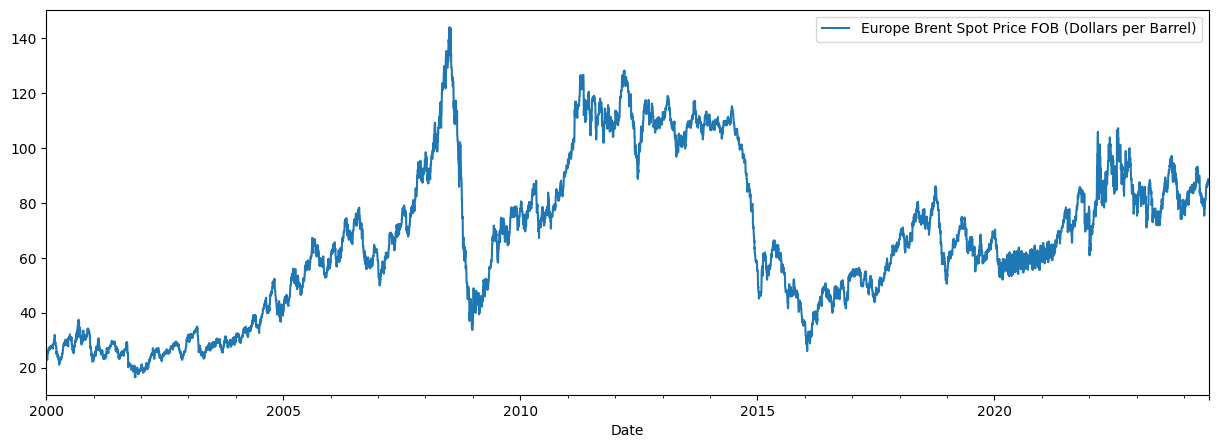

In [22]:
oil_price[['Europe Brent Spot Price FOB (Dollars per Barrel)', 'Date']].set_index('Date').plot(figsize=(15, 5));

**Insight:**

- Secara general trend cenderung naik (Trend naik dari 2004 - 2008 terus anjlok terus naik lagi sd 2013 sideways sampai 2015 turun, lalu tren naik sampe 2024)
- Pada tahun 2008 terdapat kenaikan harga minyak yang signifikan. Dan kemudian anjlok di tahun berikutnya secara signifikan juga.


# Modeling using [`prophet`](https://facebook.github.io/prophet/)

Konsep dasar dalam pemahaman kasus time series adalah dengan melakukan pemecahan komponen dari data time series (*decompose*) dimana komponen terbagi menjadi 2, yaitu:

- Trend ($T$): Pergerakan data secara general
- Seasonality ($S$): Pola yang berulang akibat kondisi musiman

*Decompose* time series ini banyak macamnya dan yang digunakan oleh `Prophet` secara default adalah metode **General Additive Model (GAM)**. Ide di balik GAM adalah ketiga komponen di atas dijumlahkan untuk menyusun data time series kita, secara matematis:

$Y(t) = T(t) + S(t)$

Dimana $Y(t)$ adalah observasi nilai time series kita.

![](assets/decom.png)

Pada konsep time series, **peramalan/forecasting time series didasari oleh kondisi/perilaku di masa lalu**. Jika disimpulkan, maka konsep untuk melakukan *forecasting* nilai masa depan adalah memperhatikan kondisi *trend* dan *seasonal* dari data time series.

## Baseline Model

### Data Preparation

Untuk menggunakan `prophet`, kita perlu mempersiapkan data time series ke dalam format yang spesifik sesuai kebutuhan library ini. `prophet` membutuhkan dataframe dengan 2 kolom berikut:
- `ds`: kolom dengan informasi waktu, harus bertipe data `datetime64[ns]`
- `y`: nilai yang ingin di-*forecast*

Pada proses ini, kita akan menggunakan `Europe Brent Spot Price FOB (Dollars per Barrel)` sebagai nilai yang ingin di-*forecast*.

Untuk mengganti nama kolom sebuah dataframe, kita dapat menggunakan method `.rename()` pada parameter `columns=`. Untuk menuliskan nama kolom yang ingin di-rename dapat menggunakan sebuah `dictionary`:

```python
df.rename(columns = {'kolom_awal' : 'kolom_baru'})
```

In [23]:
# rename column
oil_price_clean = oil_price.rename(columns={
    'Date' : 'ds',
    'Europe Brent Spot Price FOB (Dollars per Barrel)' : 'y'
})

In [24]:
# sanity check
oil_price_clean.head()

,ds,y
0,2000-01-01,23.95
1,2000-01-02,23.95
2,2000-01-03,23.95
3,2000-01-04,23.95
4,2000-01-05,23.72


In [25]:
# cek tipe data
oil_price_clean.dtypes

ds    datetime64[ns]
y            float64
dtype: object

### Fitting Model

🔻 Setelah semua persiapan data selesai. Kini kita tugaskan `prophet` untuk mencari pola dari data time series kita. 

1. Import library `prophet` dengan 
   ```python
   from prophet import Prophet
   ```
2. Membuat object untuk menyimpan model `Prophet()`
3. Menginput dataset yang akan dipelajari menggunakan method `.fit()`

In [26]:
# load library
from prophet import Prophet

# mendefinisikan object model Prophet
model_prophet = Prophet()

**💡 Notes**: Tahapan ini adalah masih pada pembuatan model yang masih kosong belum belajar

🔻 Metode `.fit()` digunakan agar model dapat belajar pola data kita. Dalam hal ini kita gunakan dataframe `oil_price_clean`

In [27]:
# fitting model
model_prophet.fit(oil_price_clean)

08:59:03 - cmdstanpy - INFO - Chain [1] start processing
08:59:10 - cmdstanpy - INFO - Chain [1] done processing


### Forecast

Karena model kita telah belajar dari pola data masa lalu, kita akan coba meramal/*forecast* data kita untuk **1 tahun ke depan**. Untuk itu kita harus mempersipakan dataframe baru yang berisi informasi waktu yang ingin di-*forecast*. Hal ini dapat dilakukan menggunakan method `.make_future_dataframe()` dari objek model kita, yaitu `model_prophet`.

Parameter `.make_future_dataframe()`:
- `periods`: Banyaknya data yang ingin di-*forecast*
- `freq`: interval data. `D` (day), `M` (month), dan lainnya.

In [28]:
# membuat dataframe baru berisikan data waktu yang lama disertai data waktu baru
future = model_prophet.make_future_dataframe(periods=365, freq='D')
future

,ds
0,2000-01-01
1,2000-01-02
2,2000-01-03
3,2000-01-04
4,2000-01-05
...,...
9316,2025-07-04
9317,2025-07-05
9318,2025-07-06
9319,2025-07-07


In [29]:
import prophet
prophet.__version__

'1.1.5'

Dataframe `future` berisi informasi tanggal tepat 365 hari setelah data fitting berakhir. Kita akan menggunakan dataframe ini untuk melakukan forecasting menggunakan method `.predict()`.

In [30]:
# Predict
forecast = model_prophet.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2000-01-01,28.69,14.35,35.71,28.69,28.69,-4.19,-4.19,-4.19,0.05,0.05,0.05,-4.23,-4.23,-4.23,0.00,0.00,0.00,24.51
1,2000-01-02,28.69,13.38,34.78,28.69,28.69,-4.19,-4.19,-4.19,0.04,0.04,0.04,-4.23,-4.23,-4.23,0.00,0.00,0.00,24.50
2,2000-01-03,28.68,14.05,34.96,28.68,28.68,-4.25,-4.25,-4.25,-0.02,-0.02,-0.02,-4.23,-4.23,-4.23,0.00,0.00,0.00,24.44
3,2000-01-04,28.68,13.84,35.53,28.68,28.68,-4.27,-4.27,-4.27,-0.04,-0.04,-0.04,-4.23,-4.23,-4.23,0.00,0.00,0.00,24.41
4,2000-01-05,28.67,14.39,34.97,28.67,28.67,-4.31,-4.31,-4.31,-0.09,-0.09,-0.09,-4.22,-4.22,-4.22,0.00,0.00,0.00,24.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316,2025-07-04,97.14,82.91,116.77,85.19,108.61,2.62,2.62,2.62,0.06,0.06,0.06,2.56,2.56,2.56,0.00,0.00,0.00,99.76
9317,2025-07-05,97.16,84.79,115.67,85.09,108.69,2.63,2.63,2.63,0.05,0.05,0.05,2.58,2.58,2.58,0.00,0.00,0.00,99.79
9318,2025-07-06,97.18,84.37,116.16,84.99,108.76,2.64,2.64,2.64,0.04,0.04,0.04,2.60,2.60,2.60,0.00,0.00,0.00,99.82
9319,2025-07-07,97.19,83.27,117.05,84.89,108.84,2.60,2.60,2.60,-0.02,-0.02,-0.02,2.62,2.62,2.62,0.00,0.00,0.00,99.79


Dari berbagai nilai di atas kita akan mengambil beberapa informasi saja, yaitu:
- `ds`: Tanggal
- `trend`: Nilai trend (pola general)
- `weekly`: Nilai seasonal weekly (pola mingguan)
- `yearly`: Nilai seasonal yearly (pola tahunan)
- `yhat`: Nilai hasil forecast


In [31]:
forecast[['ds', 'trend', 'weekly', 'yearly', 'yhat']].tail()

,ds,trend,weekly,yearly,yhat
9316,2025-07-04,97.14,0.06,2.56,99.76
9317,2025-07-05,97.16,0.05,2.58,99.79
9318,2025-07-06,97.18,0.04,2.60,99.82
9319,2025-07-07,97.19,-0.02,2.62,99.79
9320,2025-07-08,97.21,-0.04,2.63,99.80


Seperti yang sudah dibahas sebelumnya, pada konsep General Additive Model (GAM) nilai time series adalah penjumlahan dari seluruh komponen hasil *decompose*.

Pada kasus kita, terdapat 3 komponen, yaitu `trend`, seasonal `weekly` dan seasonal `yearly`. Secara matematis, hasil `yhat` (nilai time series) adalah sebagai berikut:

$yhat(t) = T(t) + S_{weekly}(t) + S_{yearly}(t)$

Secara penamaan kolom, maka persamaan di atas dibaca sebagai
`yhat` = `trend` + `weekly` + `yearly`. Berikut pembuktiannya.

In [46]:
# code here
97.14 + 0.06 + 2.56

99.76

**END OF DAY 1**

---

**START OF DAY 2**

### Visualization

Setelah membuat model dan *forecast*, dapat dilakukan visualisasi dengan method `.plot()` dari `model_prophet` dan memberikan input hasil forecast (`forecast`).

Hasil visualisasi berupa data asli (titik-titik hitam) dan hasil model fitted serta forecast (garis biru)

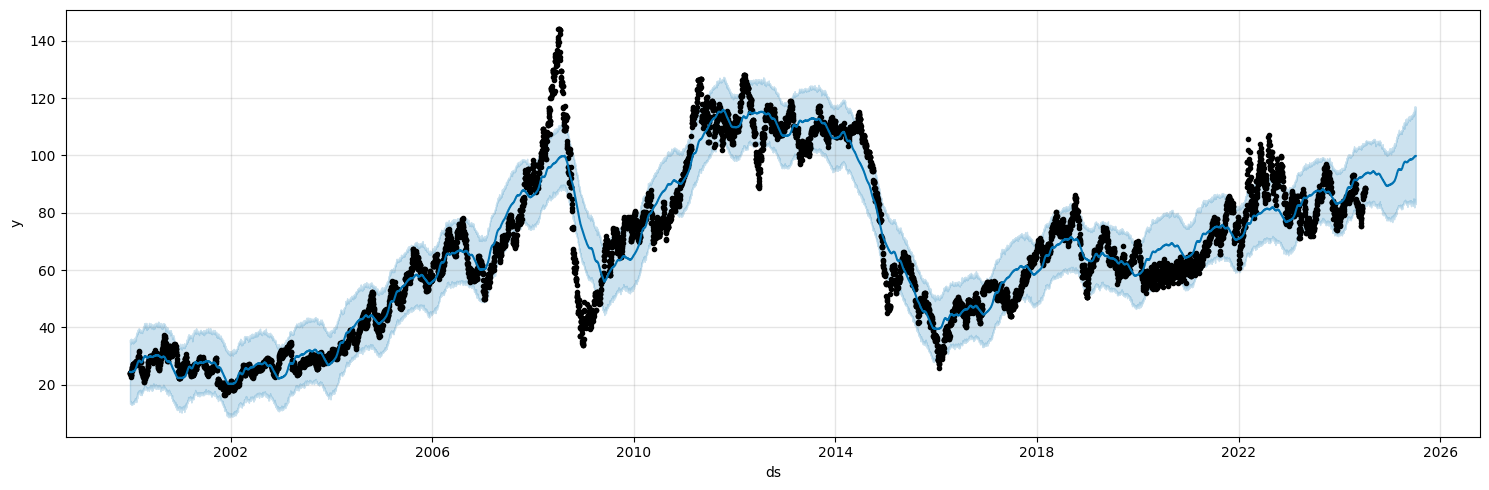

In [32]:
# code here
model_prophet.plot(forecast, figsize=(15, 5));

**Keterangan:**

- Area biru muda: range nilai prediksi harga minyak (disimpan di `yhat_upper`, `yhat_lower`)
- Garis biru tua: hasil prediksi harga minyak
- Titik data hitam: data point asli dari dataframe `oil_price_clean`.

> Secara default, model baseline `Prophet()` tidak bisa menangkap nilai-nilai ekstrim. Terutama di sekitar tahun 2008.

In [33]:
# alternative plotting
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(model_prophet, forecast)

## Model Interpretation

Dalam melakukan interpretasi, dapat dilakukan dengan memvisualisasikan setiap komponennya menggunakan method `plot_components()` dari objek `model_prophet` dan memberikan input hasil forecast (`forecast`).

In [ ]:
# code here


❓ Insight apa saja yang dapat kita ambil dari visualisasi di atas?

>

In [34]:
# alternative plotly
plot_components_plotly(model_prophet, forecast)

### Trend Component

Trend adalah pergerakan data secara general dalam jangka panjang, ditampilkan secara menurun pada data kita. 

Secara default, `Prophet` menggunakan **model linear regression** untuk mendapatkan trend yang dapat digambarkan sebagai berikut:

![trend_component.png](assets/trend_component.png)

Komponen trend time series menunjukkan pergerakan jangka panjang, ini digunakan untuk melihat pergerakan data secara jangka panjang apakah meningkat, menurun, atau tetap.

#### Automatic Changepoint Detection

Kelebihan dari `Prophet` yaitu dengan adanya *changepoint detection* yang bisa mendeteksi otomatis adanya perubahan signifikan pada trend. 

`Prophet` akan membagi data kita pada beberapa titik dan menghitung trend per bagian secara terpisah.

Changepoint yang dibuat dapat dilihat dengan menggunakan fungsi `add_changepoints_to_plot` dan memasukkan beberapa parameter seperti kode di bawah ini.

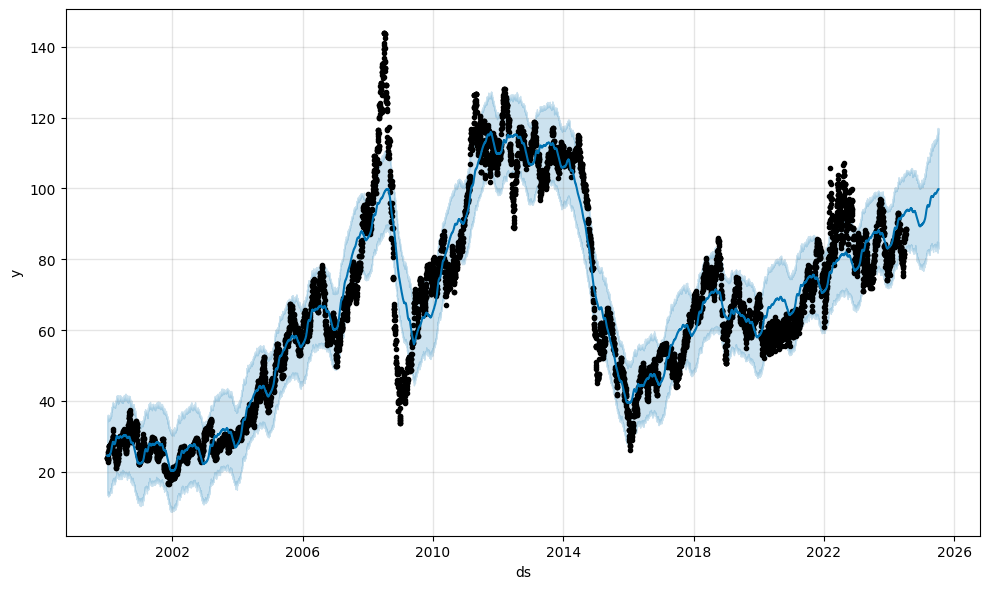

In [35]:
model_prophet.plot(forecast);

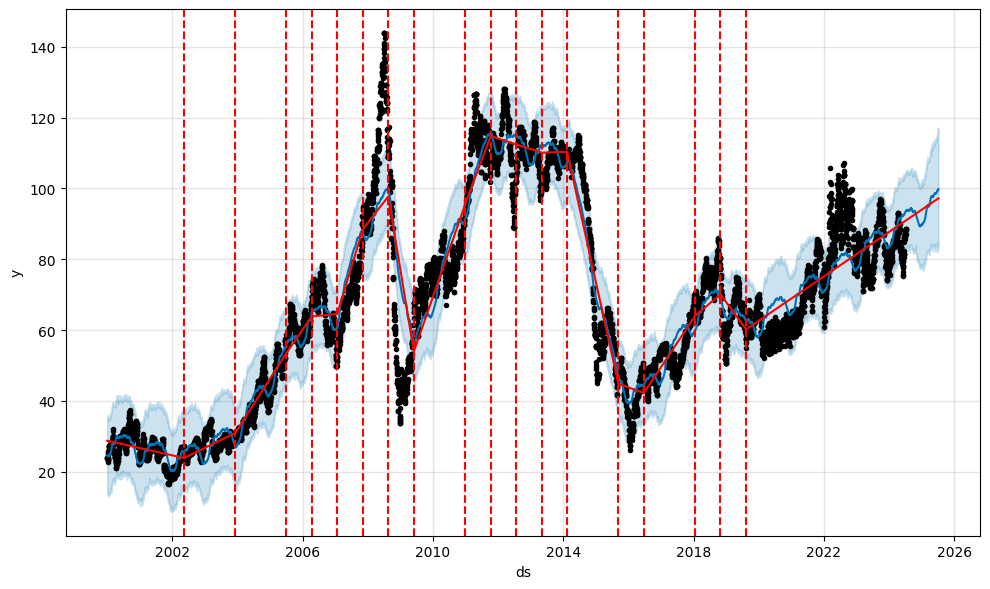

In [36]:
from prophet.plot import add_changepoints_to_plot

fig = model_prophet.plot(forecast)
a = add_changepoints_to_plot(
    ax = fig.gca(), # plot
    m = model_prophet, # model
    fcst = forecast) # hasil forecast

#### Adjusting Trend Flexibility

Jika trend dirasa terlalu fleksibel (overfit) atau kaku (underfit), Prophet menyediakan hyperparameter untuk mengubah fleksibilitas dari trend, yaitu:

- `changepoint_prior_scale` (default = 0.05): Fleksibilitas dari trend. Semakin besar nilainya, maka trend akan semakin fleksibel, begitupun pula sebaliknya.
- `n_changepoints` (default = 25): jumlah changepoint. 
- `changepoint_range` (default = 0.8 atau 80%): persentase data yang akan digunakan untuk fitting menggunakan changepoint_prior_scale

<div class="alert alert-block alert-info">
<b>Kenapa secara default changepoint hanya diterapkan di 80% data?</b> agar data time series di akhir yang digunakan untuk memproyeksikan nilai prediksi terhindar dari fluktuasi overfitting.
</div>

In [37]:
# Membuat objek prophet tuning
model_trend = Prophet(changepoint_prior_scale=0.1)
model_trend.fit(oil_price_clean)
# fitting model


09:57:27 - cmdstanpy - INFO - Chain [1] start processing
09:57:31 - cmdstanpy - INFO - Chain [1] done processing


Mari kita coba memprediksi 365 hari kedepan menggunakan model yang telah dituning

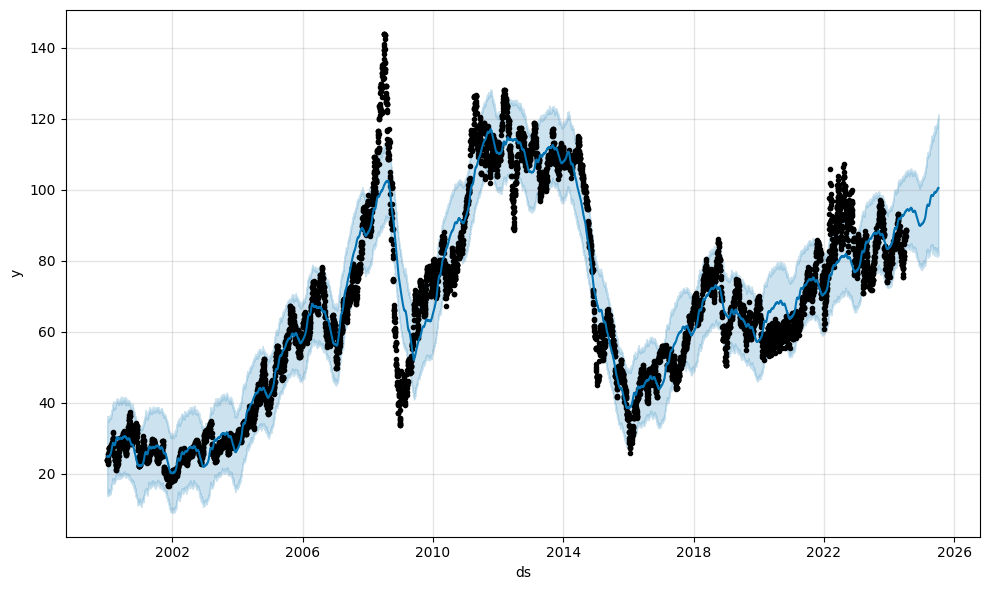

In [39]:
# make time window to predict
future_trend = model_trend.make_future_dataframe(periods=365, freq='D')

# predict future dataframe
forecast_trend = model_trend.predict(future_trend)

# visualize components
model_trend.plot(forecast_trend);

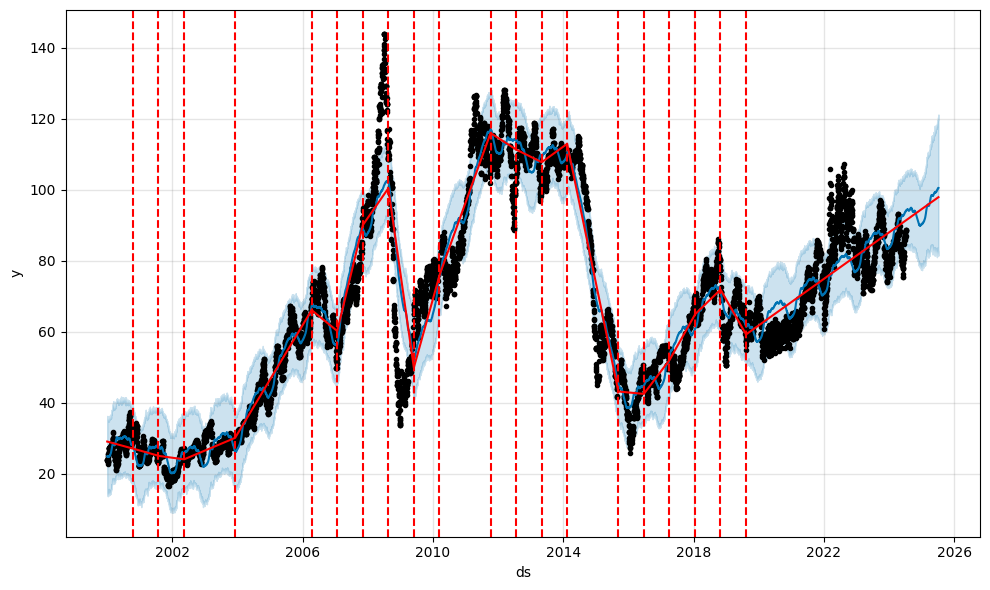

In [40]:
# Visualisasi changepoint
fig = model_trend.plot(forecast_trend)

a = add_changepoints_to_plot(fig.gca(),
                             model_trend,
                             forecast_trend)

### Seasonality Component

Selain dapat mengubah pengaturan komponen dari trend, kita juga dapat mengubah pengaturan dari komponen seasonality.

Seasonality adalah pola berulang untuk periode waktu tertentu. Seperti pola berulang untuk periode mingguan, bulanan atau tahunan.

Mari kita lihat lagi komponen pada data time series kita.

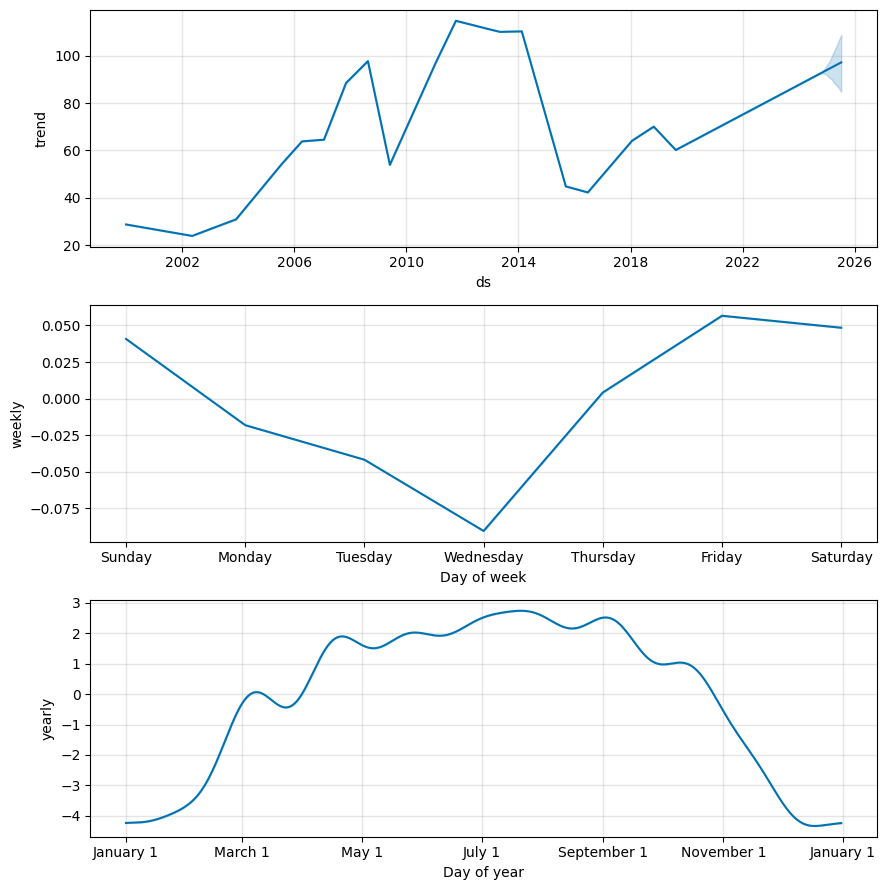

In [41]:
model_prophet.plot_components(forecast);

Secara default, Prophet akan menentukan kondisi seasonal berdasarkan periodikal data yang disediakan. Pada kasus kita, data tersusun dari Januari 2020 sampai Juli 2024.

- **weekly seasonality** akan digunakan jika terdapat data lebih dari 2 minggu observasi.
- **yearly seasonality** akan digunakan jika terdapat data lebih dari 2 tahun observasi.
- Komponen seasonal lain yang tidak terdeteksi pada kasus kita adalah **daily seasonality** yang berusaha mencari pola data dengan periode jam. Karena data kita tidak memiliki informasi jam, secara default nilai dari parameter ini adalah `False`.

#### Math Behind Seasonality - FOURIER ORDER

Prophet menggunakan deret Fourier untuk menentukan efek seasonal, metode ini bekerja dengan membuat fungsi periodik yang berisi **penjumlahan dari fungsi gelombang sin** (yang jumlahnya tidak terbatas).

💡 Fourier order dapat ditentukan menggunakan sebuah parameter, parameter ini akan menetapkan seberapa cepat seasonality berubah. Dengan meningkatkan order, kita dapat membuat seasonality yang dihasilkan menjadi lebih fleksibel (dan mungkin menyebabkan model menjadi overfit), begitu pula sebaliknya. Berikut gambaran order:

![](assets/fourier.svg)

Berikut gambaran interaktif tentang Fourier: http://www.jezzamon.com/fourier/

> Secara default, nilai order dari:
> - `weekly_seasonality = 3`  
> - `yearly_seasonality = 10`

Kita akan coba lihat pengaruhnya dengan mengatur kedua parameter di atas ketika membuat object.

In [42]:
# tuning seasonality
model_seasonality = Prophet(yearly_seasonality=100)

# model fitting
model_seasonality.fit(oil_price_clean);

10:18:19 - cmdstanpy - INFO - Chain [1] start processing
10:18:36 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# forecasting
future_seasonality = model_seasonality.make_future_dataframe(periods = 365, freq = 'D')
forecast_seasonality = model_seasonality.predict(future_seasonality)

Selanjutnya kita bandingkan `plot_components()` untuk model baseline dan juga model hasil tuning yearly seasonal dengan order Fourier 100

In [ ]:
# model tuned seasonality
model_seasonality.plot_components(forecast_seasonality);

In [ ]:
# model tuned seasonality
model_seasonality.plot(forecast_seasonality);

Insight :
> Yearly Seasonality lebih banyak menangkap perubahan jumlah transaksi setiap awal bulan

#### Custom Seasonality

Harga minyak mentah (crude oil) bisa dipengaruhi oleh pola musiman (seasonality) dan jenis musimannya biasanya adalah seasonal tahunan (yearly seasonality). 

Yearly seasonality dapat terjadi karena kondisi cuaca (winter season), maintenance kilang minyak, produksi pertanian, hari libur besar, dan lain-lain. Seasonality bulanan (monthly) dan mingguan (weekly) memiliki pengaruh yang lebih kecil dan kurang signifikan dibandingkan dengan seasonality tahunan.

Seasonality default Prophet model untuk data harian adalah `weekly` dan `yearly`. Tetapi semisal terdapat kasus bisnis seperti berikut:

> Perusahaan minyak sering kali melaporkan hasil keuangan mereka setiap bulan, yang dapat mempengaruhi harga saham mereka dan, secara tidak langsung, harga minyak mentah.

Karena kondisi tersebut tidak ditangkap oleh seasonal weekly dan yearly saja, maka perlu dilakukan custom seasonality. 

Custom seasonality dapat dilakukan dengan cara:

- **Menghilangkan efek seasonal default**, contoh:

  `yearly_seasonality = False`

- **Menambahkan seasonality tambahan**, menggunakan method `.add_seasonality()` setelah membuat object Prophet dan sebelum melakukan fitting.

  Pada fungsi `.add_seasonality()`, terdapat 3 parameter yang dapat kita manfaatkan, yaitu:
  - `name`: Nama pada pengaturan seasonality
  - `period`: Jumlah **hari** pada pola seasonality yang ingin dianalisa
  - `fourier_order`: Jumlah fourier order untuk pola seasonality

**Contoh Add Monthly Seasonality**

Buatlah sebuah model seasonality dengan tambahan seasonality bulanan (monthly)!

In [44]:
# fitting model
model_monthly = Prophet()

# add seasonality monthly
model_monthly.add_seasonality(name='monthly',
                                period=30.5,
                                fourier_order=5)


10:55:34 - cmdstanpy - INFO - Chain [1] start processing
10:55:39 - cmdstanpy - INFO - Chain [1] done processing


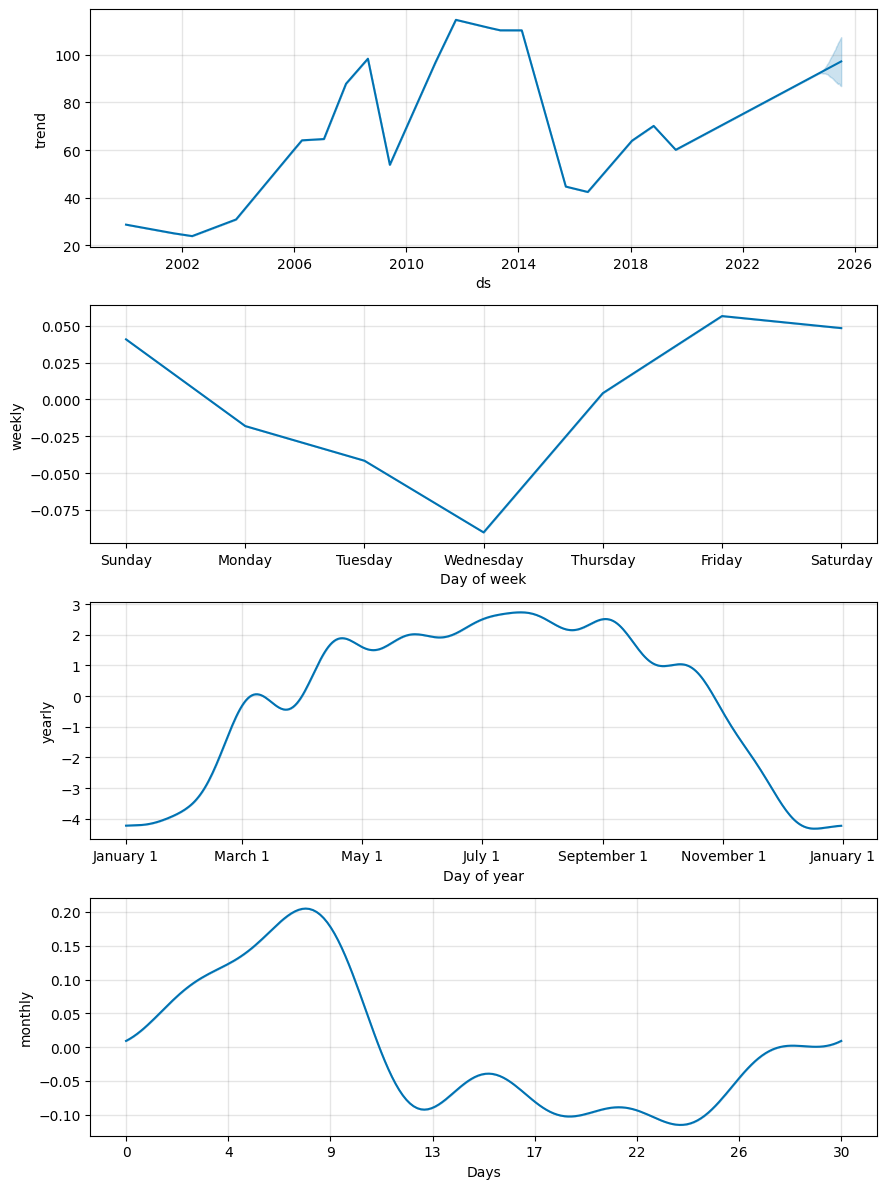

In [45]:
# model fitting
model_monthly.fit(oil_price_clean)

# forecasting
future_monthly = model_monthly.make_future_dataframe(periods = 365, freq = 'D')
forecast_monthly = model_monthly.predict(future_monthly)

# visualize
model_monthly.plot_components(forecast_monthly);

Jika kita perhatikan, terdapat seasonality baru, yaitu `bulanan`. Sehingga rumus *forecast* akan menjadi:

$yhat(t) = T(t) + S_{yearly}(t) + S_{weekly}(t) + S_{monthly}(t)$

💡 Insight dari monthly seasonality?

> ...

💡 **Note:** Nilai Fourier order yang direkomendasikan berdasarkan seasonalnya:

- weekly seasonality = 3
- monthly seasonality = 5
- yearly seasonality = 10

### **Summary: Workflow Analisis Time Series dengan Prophet**

- Terdapat 3 syarat data time series:
  
  1. Data harus berurutan
  2. Memiliki interval yang tetap (jam, harian, mingguan)
  3. Data tanggal berupa datetime64[ns]

- Dataframe perlu diubah menjadi 2 kolom saja:

   1. `ds` : Datetime
   2. `y` : kolom yang ingin di forecast

- Workflow forecasting:

    - Mengimport prophet melalui `from prophet import Prophet`
    
    - Mendefinisikan variabel penyimpan object model
    
    - menginput data ke model menggunakan `.fit()`
 
    - Membuat dataframe masa depan menggunakan `.make_future_dataframe()`
 
    - Melakukan forecasting menggunakan `.predict()`
 
    - Terdapat 2 jenis visualisasi untuk menginterpretasi forecast:
 
      1. `.plot()` untuk hasil forecast
      2. `.plot_components()` untuk visualisasi komponen
         
    - Prophet membuat model dengan melakukan decompose component time series:
 
      1. Trend
      2. Daily Seasonality
      3. Weekly Seasonality
      4. Yearly Seasonality

## [Holiday Effects](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#modeling-holidays-and-special-events)

Salah satu keuntungan dari penggunaan Prophet adalah kemampuannya untuk memperhitungkan efek liburan. **Holiday effect** didefinisikan sebagai efek non-regular yang disiapkan secara manual oleh user.

### Modelling Holidays and Special Events

Sekarang kita akan melihat visualisasi dari model pertama yang kita buat.

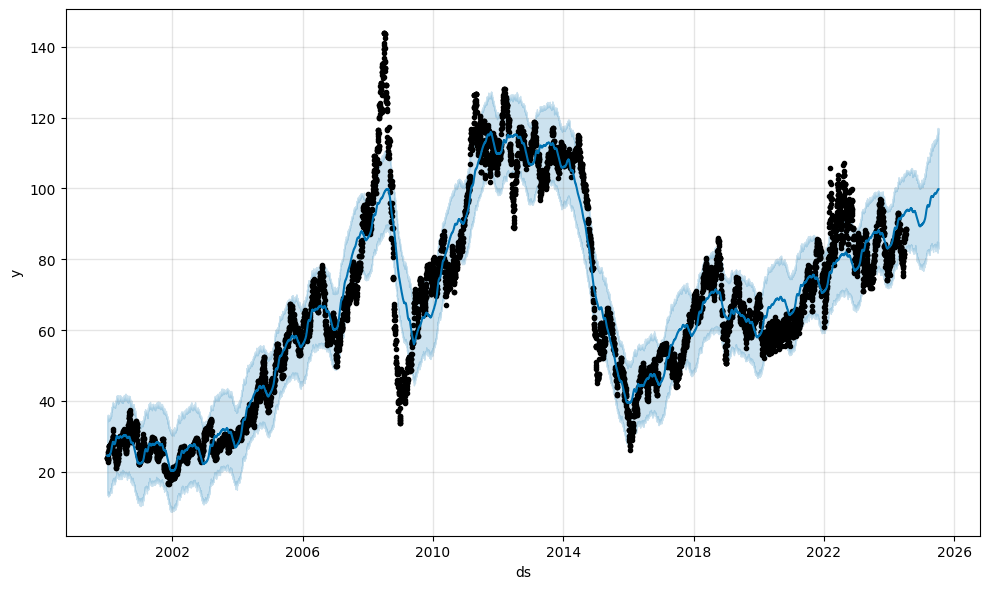

In [46]:
model_prophet.plot(forecast);

Dari sini kita dapat mempersiapkan sebuah dataframe yang memiliki informasi data holiday yang akan kita atur.

Kolom-kolom yang harus dipersiapkan, yaitu:

- `holiday`: nama hari libur yang nilainya unik
- `ds`: informasi waktu
- `lower_window`: jumlah periode waktu **sebelum** tanggal hari libur yang diasumsikan memiliki pengaruh (<= 0)
- `upper_window`: jumlah periode waktu **setelah** tanggal hari libur yang diasumsikan memiliki pengaruh (>= 0)

⚠️ Informasi ini harus mencakup seluruh kejadian yang akan kita gunakan, baik pada model fitting maupun forecast. 

Ada beberapa kejadian berulang yang mungkin dapat mempengaruhi harga minyak Brent secara periodik, salah satunya adalah pertemuan OPEC. OPEC (Organization of the Petroleum Exporting Countries) adalah organisasi internasional yang terdiri dari beberapa negara penghasil minyak terbesar di dunia.  OPEC mengadakan pertemuan reguler (biasanya dua kali setahun) untuk memutuskan kebijakan produksi minyak. Keputusan untuk mengurangi atau meningkatkan produksi dapat berdampak signifikan pada harga minyak. Mari kita coba masukan [tanggal pertemuan OPEC](https://www.investing.com/economic-calendar/opec-meeting-230):

In [47]:
opec_meeting = pd.read_csv('data_input/opec_meeting.csv', parse_dates=['ds'])
opec_meeting.head()

,holiday,ds,lower_window,upper_window
0,opec_meeting,2024-06-02,0,2
1,opec_meeting,2024-04-03,0,2
2,opec_meeting,2024-02-01,0,2
3,opec_meeting,2023-11-30,0,2
4,opec_meeting,2023-10-04,0,2


Setelah dataframe `opec_meeting` dipersiapkan, kita perlu memasukkan informasi ini ke dalam `Prophet()` di parameter `holidays`.

In [48]:
# membuat objek model
model_holiday = Prophet(holidays=opec_meeting) # menambahkan dataframe hari libur

# fit
model_holiday.fit(oil_price_clean);

11:18:05 - cmdstanpy - INFO - Chain [1] start processing
11:18:08 - cmdstanpy - INFO - Chain [1] done processing


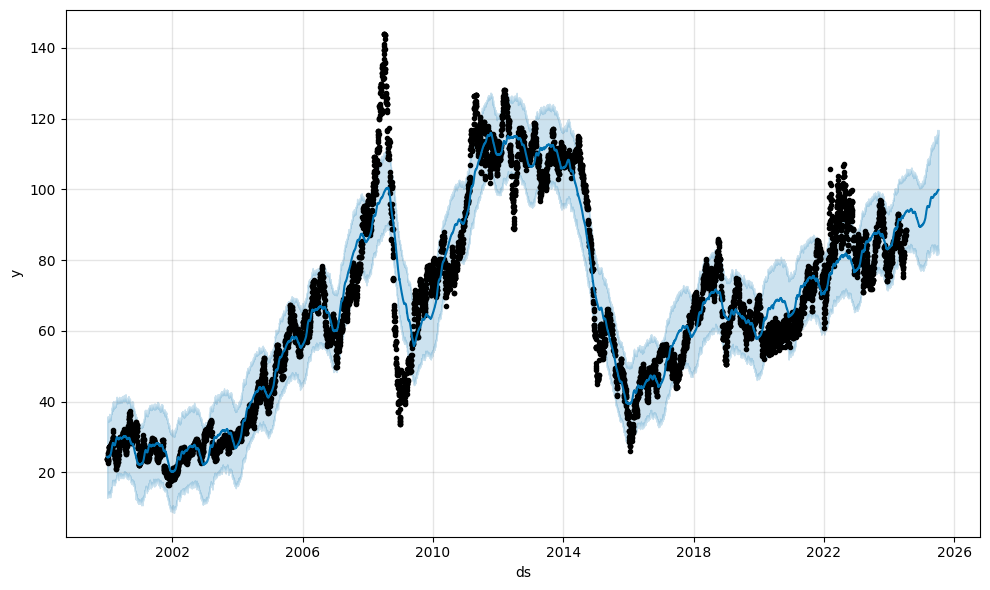

In [49]:
# Forecasting
future_holiday = model_holiday.make_future_dataframe(periods = 365, freq = 'D')
forecast_holiday = model_holiday.predict(future_holiday)

# visualize
model_holiday.plot(forecast_holiday);



Mari kita lihat komponen model:

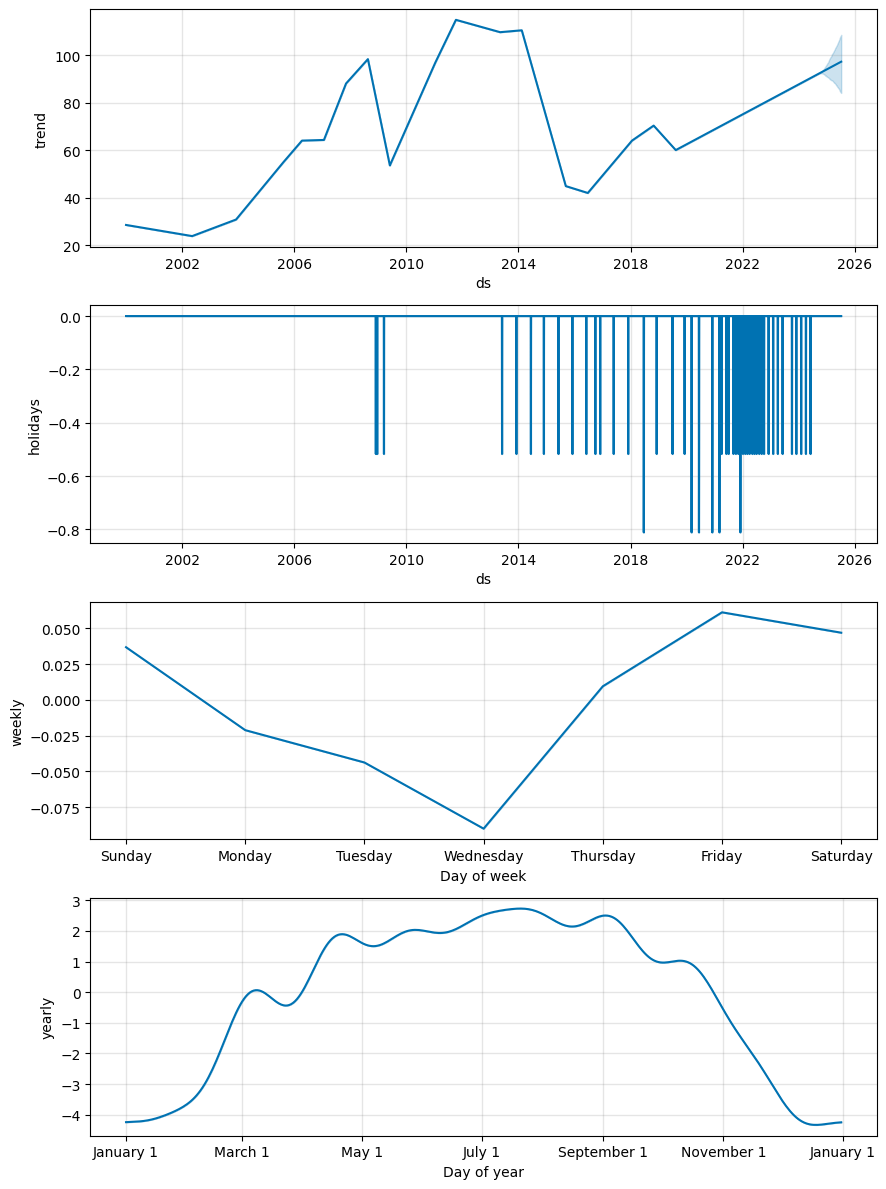

In [50]:
model_holiday.plot_components(forecast_holiday);

> Insight: ...

# Model Evaluation 

Proses model evaluation mengukur seberapa baik performa model time series dalam memprediksi atau melakukan forecasting data time series dengan menghitung besar **error/selisih** nya dibandingkan dengan data aktualnya. Namun, sebelum kita dapat mengevaluasi hasil forecast dari model time series, kita akan melakukan proses Train-Test Splitting terlebih dahulu

## Train-Test Splitting

Train-Test Splitting adalah metode yang kita gunakan untuk mengetahui seberapa baik performa model kita memprediksi terhadap data baru.

Lantas, bagaimana cara mengetahui apakah model yang kita buat telah baik dalam memprediksi data baru? Di sinilah mengapa kita melakukan Train-test splitting. Kita membagi data kita menjadi 2 kelompok, yaitu data `train` dan `test`.

![cv.png](assets/cv.png)

- **Train data**: Data yang digunakan untuk pelatihan model. Model akan mendapatkan pola trend dan seasonal.
- **Test data**: sebagai *unseen data* untuk menguji performa model. Model akan mencoba memprediksi masa depan sesuai dengan data test.

Jika diibaratkan, seorang siswa dapat dikatakan pintar ketika dapat menjawab benar soal-soal ujian yang tidak pernah dikerjakannya pada soal-soal latihan untuk persiapan ujian.

Data `train` diibaratkan soal latihan, dan data `test` diibaratkan soal ujian. Adapun `model` kita diibaratkan sebagai siswa.

💡 Konsep Train Test Splitting untuk model Time Series memiliki **kriteria yang harus dipenuhi**, yaitu:

- **Train data** menggunakan data awal
- **Test data** menggunakan data akhir

Pemisahan kedua data seperti di atas dengan mudah dapat kita lakukan dengan conditional subsetting. 

📝 **Note** : data train sebaiknya lebih banyak dibandingkan data test.

🦉 **Tips**: pemotongan data train dan data test biasanya memperhatikan pola seasonal (misal, seasonal tahunan, bulanan, harian, per dekade, per semester, dll) apa yang ingin diamati. Minimal ada dua kali periode seosonal paling panjang yang ingin ditinjau. Misal, jika Anda ingin melihat pola seasonal tahunan dan bulanan, maka data train minimal memiliki range 2 tahun.

In [72]:
oil_price_clean.describe()

,ds,y
count,8956,"8,956.00"
mean,2012-04-04 12:00:00,66.70
min,2000-01-01 00:00:00,16.51
25%,2006-02-16 18:00:00,46.14
50%,2012-04-04 12:00:00,64.49
75%,2018-05-22 06:00:00,85.22
max,2024-07-08 00:00:00,143.95
std,NaN,28.02


Data kita memiliki range waktu dari Januari 2000 hingga July 2024. Misal, pola seasonal paling panjang yang akan kita amati adalah pola tahunan. Maka, kita punya cukup fleksibilitas dalam splitting data train dan data test ini. Sebagai permulaan, kita potong data train dan test di tahun 2020 bulan Januari:

In [73]:
oil_train = oil_price_clean[(oil_price_clean['ds'] < '2020-01-01')]
oil_test = oil_price_clean[oil_price_clean['ds'] >= '2020-01-01']

print(f'Train size: {oil_train.shape}')
print(f'Test size: {oil_test.shape}')

Train size: (7305, 2)
Test size: (1651, 2)


Sekarang mari kita latih model kita menggunakan data tahun 2020-2019 (`train`) dan forecast untuk tahun 2020 sampai 2024 (`test`)

Buat model dengan spesifikasi berikut!

- Ubah `changepoint_prior_scale` menjadi lebih rendah dari default (0.05) agar model tidak menangkap banyak noise. 
- Ubah `changepoint_range` menjadi lebih tinggi dari default (0.8 atau 80%) agar model dapat menangkap trend di akhir
- Tambahkan **monthly** seasonality dengan `period = 30.5` dan `fourier_order = 5`.

In [74]:
# fitting model
model_final = Prophet(changepoint_prior_scale=0.01,changepoint_range=0.9,)

# add seasonality
model_final.add_seasonality(name='monthly',
                              period=30.5,
                              fourier_order=5)

# fit dengan train
model_final.fit(oil_train)

13:35:34 - cmdstanpy - INFO - Chain [1] start processing
13:35:35 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
# forecasting
future_final = model_final.make_future_dataframe(periods = oil_test.shape[0], freq = 'D')
forecast_final = model_final.predict(future_final)

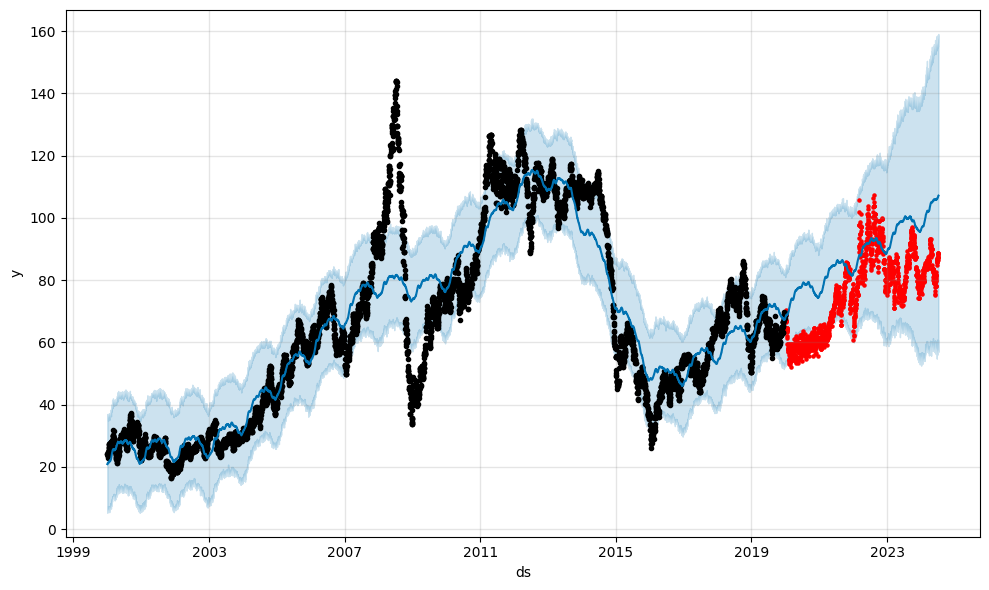

In [76]:
# visualize
import matplotlib.pyplot as plt

fig = model_final.plot(forecast_final)
plt.scatter(x = oil_test['ds'], y = oil_test['y'], color = 'red', s = 5);
plt.savefig('forecast_final.png') # Export plot to image (png)

## Evaluation Metrics

Setelah kita melakukan *forecast*, mari kita lakukan evaluasi performa model kita dengan membandingkannya terhadap nilai aktual data test kita. **Perbedaan antara nilai *forecast* dengan nilai aktual disebut sebagai *error***, semakin kecil *error* maka semakin bagus model kita, karena nilai *forecast* semakin mendekati nilai aslinya.

Kita akan mempersiapkan data hasil forecasting kita khusus untuk data test (hasil prediksi untuk tanggal setelah `1 Januari 2020`)

In [77]:
# subset test data forecasts
forecast_test = forecast_final[forecast_final['ds'] >= '2020-01-01']

In [78]:
# sanity check: shape
forecast_test.shape, oil_test.shape

((1651, 22), (1651, 2))

Terdapat beberapa perhitungan untuk mengevaluasi error model secara keseluruhan, perhitungan / metriks tersebut antara lain:

### Mean Absolute Error (MAE)

Rata-rata seberapa menyimpang hasil *forecast* terhadap data aktual. Dipengaruhi oleh skala data.

$$
MAE = \frac{\sum_{i=1}^{n}| y-\hat y|}{n} 
$$

📝 **Note** : Dengan mengetahui nilai MAE, kita dapat mengira-ngira seberapa besar selisih kesalahan prediksi model

🔻 Fungsi `mean_absolute_error()` memungkinkan kita untuk menghitung *Mean Absolute Error*, kita dapat menggunkaan fungsi `mean_absolute_error` dari `sklearn.metrics`.

 Parameter yang dimasukkan adalah;
* `y_true` : data target aktual (*ground truth*) yang akan dijadikan acuan nilai sebenarnya
* `y_pred` : data target hasil prediksi/forecast model

In [79]:
from sklearn.metrics import mean_absolute_error

In [80]:
mae = mean_absolute_error(oil_test['y'], forecast_test['yhat'])
mae

13.017345281479502

💡 **Interpretasi**:



### Mean Absolute Percentage Error (MAPE)

Rata-rata seberapa menyimpang hasil *forecast* terhadap data aktual tapi dalam bentuk persentase, sehingga tidak dipengaruhi oleh skala data.


$$
MAPE = \frac{1}{n}\Sigma{\frac{| y-\hat y|}{y}}
$$ 

📝 **Note** : MAPE memiliki kekurangan yaitu tidak bisa digunakan jika terdapat nilai 0 pada data

In [83]:
# library preparation
from sklearn.metrics import mean_absolute_percentage_error

In [84]:
mape = mean_absolute_percentage_error(oil_test['y'], forecast_test['yhat'])
mape

0.1844665944469969

In [95]:
forecast_test_holiday = forecast_holiday[(forecast_holiday['ds'] >= oil_test['ds'].min()) & (forecast_holiday['ds'] <= oil_test['ds'].max())]
forecast_test_holiday.shape[0], oil_test.shape[0]
print(f'MAPE holiday model: {mean_absolute_percentage_error(oil_test["y"], forecast_test_holiday["yhat"])}')
print(f'MAE holiday model: {mean_absolute_error(oil_test["y"], forecast_test_holiday["yhat"])}')

MAPE holiday model: 0.09062988817527112
MAE holiday model: 6.804693266725736


In [97]:
forecast_test_monthly = forecast_monthly[(forecast_monthly['ds'] >= oil_test['ds'].min()) & (forecast_monthly['ds'] <= oil_test['ds'].max())]
forecast_test_monthly.shape[0], oil_test.shape[0]
print(f'MAPE holiday model: {mean_absolute_percentage_error(oil_test["y"], forecast_test_monthly["yhat"])}')
print(f'MAE holiday model: {mean_absolute_error(oil_test["y"], forecast_test_monthly["yhat"])}')

MAPE holiday model: 0.09067291827078978
MAE holiday model: 6.803398846121953


💡 **Interpretasi**:


# Hyperparameter Tuning

Setiap analyst pasti menginginkan model dengan performa terbaik.

Maka dari itu terdapat *hyperparameter* di dalam sebuah model machine learning, *hyperparameter* adalah parameter-parameter yang dapat diatur oleh pembuat model untuk mempengaruhi cara belajar dari sebuah model. Dengan mengatur *hyperparameter* yang tepat, kita dapat meningkatkan performa model kita.

Analogi sederhana dari mengatur *hyperparameter* ini adalah adalah seperti instruksi seorang koki ketika membuat resep, ada beberapa hal yang dapat diatur yang dapat mempengaruhi cita rasa makanan, seperti jumlah garam, waktu memasak, atau suhu oven. Hal-hal tersebut adalah *hyperparameter* dalam membuat sebuah hidangan.

💡**Reminder** : Nilai Fourier order yang direkomendasikan berdasarkan seasonalnya:

- weekly seasonality = 3
- monthly seasonality = 5
- yearly seasonality = 10

⚒ **Dive Deeper**: Berdasarkan seluruh parameter dan customization yang telah kita pelajari, lakukan hyperparameter tuning yang akan menghasilkan model dengan performa (`MAE` dan `MAPE`) lebih baik dibandingkan `model_final`!

In [105]:
import itertools
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# ---- Assume your data is ready ----
# oil_train: DataFrame with 'ds' and 'y' columns
# opec_meeting: DataFrame with holidays

# Define your parameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'fourier_order': [3, 5, 7, 10]  # tune your monthly seasonality
}

# Prepare combinations of all parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

# Split data: train/test
train = oil_train.copy()
test_start = '2020-01-01'
test = oil_test
train = oil_train

# To store results
mae_list = []

for params in all_params:
    model = Prophet(
        weekly_seasonality=3,
        yearly_seasonality=10,
        holidays=opec_meeting,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale']
    )

    # add custom monthly seasonality with tuned fourier order
    model.add_seasonality(
        name='monthly',
        period=30.5,
        fourier_order=params['fourier_order']
    )

    # fit model
    model.fit(train)

    # forecast
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)

    # evaluate MAE only on test range
    y_true = test['y'].values
    y_pred = forecast.set_index('ds').loc[test['ds'], 'yhat'].values

    mae = mean_absolute_error(y_true, y_pred)
    mae_list.append(mae)

    print(f"Params: {params} => MAE: {mae:.4f}")

# Find best result
best_params = all_params[mae_list.index(min(mae_list))]
print("\n✅ Best Parameters:", best_params)
print(f"✅ Best MAE: {min(mae_list):.4f}")

# Train final model with best params
best_model = Prophet(
    weekly_seasonality=3,
    yearly_seasonality=10,
    holidays=opec_meeting,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale']
)
best_model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=best_params['fourier_order']
)
best_model.fit(oil_train)

# Final forecast
future_tuning = best_model.make_future_dataframe(periods=1651, freq="D")
forecast_tuning = best_model.predict(future_tuning)
forecast_test_tuning = forecast_tuning[forecast_tuning['ds'] >= '2020-01-01']


14:02:33 - cmdstanpy - INFO - Chain [1] start processing
14:02:33 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'fourier_order': 3} => MAE: 30.4502


14:02:35 - cmdstanpy - INFO - Chain [1] start processing
14:02:35 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'fourier_order': 5} => MAE: 30.1845


14:02:37 - cmdstanpy - INFO - Chain [1] start processing
14:02:37 - cmdstanpy - INFO - Chain [1] done processing


...

14:07:08 - cmdstanpy - INFO - Chain [1] start processing
14:07:13 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'fourier_order': 7} => MAE: 15.6768


14:07:15 - cmdstanpy - INFO - Chain [1] start processing
14:07:20 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'fourier_order': 10} => MAE: 15.6569

✅ Best Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'fourier_order': 7}
✅ Best MAE: 11.1160


14:07:23 - cmdstanpy - INFO - Chain [1] start processing
14:07:25 - cmdstanpy - INFO - Chain [1] done processing


In [115]:
train

,ds,y
0,2000-01-01,23.95
1,2000-01-02,23.95
2,2000-01-03,23.95
3,2000-01-04,23.95
4,2000-01-05,23.72
...,...,...
7300,2019-12-27,68.91
7301,2019-12-28,68.91
7302,2019-12-29,68.91
7303,2019-12-30,68.30


In [106]:
import itertools
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# ---- Assume your data is ready ----
# oil_train: DataFrame with 'ds' and 'y' columns
# opec_meeting: DataFrame with holidays

# Define your parameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'fourier_order': [3, 5, 7, 10]  # tune your monthly seasonality
}

# Prepare combinations of all parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

# Split data: train/test
train = oil_train.copy()
test_start = '2020-01-01'
test = oil_test
train = oil_train

# To store results
mae_list = []

for params in all_params:
    model = Prophet(
        weekly_seasonality=3,
        yearly_seasonality=10,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale']
    )

    # add custom monthly seasonality with tuned fourier order
    model.add_seasonality(
        name='monthly',
        period=30.5,
        fourier_order=params['fourier_order']
    )

    # fit model
    model.fit(train)

    # forecast
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)

    # evaluate MAE only on test range
    y_true = test['y'].values
    y_pred = forecast.set_index('ds').loc[test['ds'], 'yhat'].values

    mae = mean_absolute_error(y_true, y_pred)
    mae_list.append(mae)

    print(f"Params: {params} => MAE: {mae:.4f}")

# Find best result
best_params = all_params[mae_list.index(min(mae_list))]
print("\n✅ Best Parameters:", best_params)
print(f"✅ Best MAE: {min(mae_list):.4f}")

# Train final model with best params
best_model = Prophet(
    weekly_seasonality=3,
    yearly_seasonality=10,
    holidays=opec_meeting,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale']
)
best_model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=best_params['fourier_order']
)
best_model.fit(oil_train)

# Final forecast
future_tuning = best_model.make_future_dataframe(periods=1651, freq="D")
forecast_tuning = best_model.predict(future_tuning)
forecast_test_tuning = forecast_tuning[forecast_tuning['ds'] >= '2020-01-01']


14:08:04 - cmdstanpy - INFO - Chain [1] start processing
14:08:04 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'fourier_order': 3} => MAE: 29.3748


14:08:06 - cmdstanpy - INFO - Chain [1] start processing
14:08:06 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'fourier_order': 5} => MAE: 30.3215


14:08:08 - cmdstanpy - INFO - Chain [1] start processing
14:08:08 - cmdstanpy - INFO - Chain [1] done processing


...

14:12:10 - cmdstanpy - INFO - Chain [1] start processing
14:12:13 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'fourier_order': 7} => MAE: 15.5652


14:12:15 - cmdstanpy - INFO - Chain [1] start processing
14:12:18 - cmdstanpy - INFO - Chain [1] done processing


Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'fourier_order': 10} => MAE: 15.5960

✅ Best Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'fourier_order': 3}
✅ Best MAE: 11.2470


14:12:20 - cmdstanpy - INFO - Chain [1] start processing
14:12:21 - cmdstanpy - INFO - Chain [1] done processing


In [116]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Ensure datetime columns
oil_train['ds'] = pd.to_datetime(oil_train['ds'])
oil_test['ds'] = pd.to_datetime(oil_test['ds'])

# Test period fixed
test = oil_test[oil_test['ds'] >= '2020-01-01']

# Try multiple training start dates
train_start_dates = [
    '2000-01-01',
    '2005-01-01',
    '2010-01-01',
    '2015-01-01',
    '2018-01-01'
]

results = []

for start_date in train_start_dates:
    # Select subset of training data
    train_subset = oil_train[oil_train['ds'] >= start_date]

    print(f"\nTraining from {start_date} to {train_subset['ds'].max().date()} (n={len(train_subset)})")

    # Build Prophet model (you can reuse tuned params or your preferred settings)
    model = Prophet(
        weekly_seasonality=3,
        yearly_seasonality=10,
        holidays=opec_meeting,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=1.0
    )
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model.fit(train_subset)

    # Forecast into the test period
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)

    # Evaluate on test
    y_true = test['y'].values
    y_pred = forecast.set_index('ds').loc[test['ds'], 'yhat'].values

    mae = mean_absolute_error(y_true, y_pred)
    results.append({'train_start': start_date, 'mae': mae})
    print(f"MAE: {mae:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values('mae')
print("\n✅ Training Range Comparison:")
print(results_df)

# Best start date
best_start = results_df.iloc[0]['train_start']
print(f"\n🏆 Best training start date: {best_start} (MAE = {results_df.iloc[0]['mae']:.4f})")



Training from 2000-01-01 to 2019-12-31 (n=7305)


14:22:59 - cmdstanpy - INFO - Chain [1] start processing
14:23:03 - cmdstanpy - INFO - Chain [1] done processing


MAE: 15.6730

Training from 2005-01-01 to 2019-12-31 (n=5478)


14:23:05 - cmdstanpy - INFO - Chain [1] start processing
14:23:07 - cmdstanpy - INFO - Chain [1] done processing


MAE: 9.5974

Training from 2010-01-01 to 2019-12-31 (n=3652)


...

MAE: 24.7051

Training from 2015-01-01 to 2019-12-31 (n=1826)


14:23:11 - cmdstanpy - INFO - Chain [1] start processing
14:23:13 - cmdstanpy - INFO - Chain [1] done processing


MAE: 13.4262

Training from 2018-01-01 to 2019-12-31 (n=730)


14:23:14 - cmdstanpy - INFO - Chain [1] start processing
14:23:14 - cmdstanpy - INFO - Chain [1] done processing


MAE: 75.5489

✅ Training Range Comparison:
  train_start   mae
1  2005-01-01  9.60
3  2015-01-01 13.43
0  2000-01-01 15.67
2  2010-01-01 24.71
4  2018-01-01 75.55

🏆 Best training start date: 2005-01-01 (MAE = 9.5974)


In [140]:
# fit dengan train
# tuning fourier order model
model_tuning = Prophet(
    weekly_seasonality=3,
    yearly_seasonality=10,
    holidays=opec_meeting,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=1.0
)
# add seasonality
model_tuning.add_seasonality(name='monthly',
                              period=30.5,
                              fourier_order=7)

model_tuning.fit(oil_train[oil_train['ds'] >= '2005-01-01'])

# forecasting
future_tuning = model_tuning.make_future_dataframe(periods=1651, freq="D")
forecast_tuning = model_tuning.predict(future_tuning)

forecast_test_tuning = forecast_tuning[forecast_tuning['ds'] >= '2020-01-01']

mae_tuning = mean_absolute_error(y_true=oil_test['y'],
                                            y_pred=forecast_test_tuning['yhat'])
print(f"mae tuning:{mae_tuning}")

mape_tuning = mean_absolute_percentage_error(y_true=oil_test['y'],
                                            y_pred=forecast_test_tuning['yhat'])
print(f"mape tuning:{round(mape_tuning*100,3)}%")

14:36:08 - cmdstanpy - INFO - Chain [1] start processing
14:36:10 - cmdstanpy - INFO - Chain [1] done processing


mae tuning:9.54446257764849
mape tuning:13.7%


## [Optional] Built-in Country Holidays

Kita dapat menggunakan informasi built-in tentang hari libur spesifik suatu negara menggunakan method `.add_country_holidays()` sebelum melakukan fitting model. Parameter yang harus ditambahkan yaitu `country_name` dan untuk Indonesia masukkan nilai `"ID"`

In [141]:
model_holiday_us = Prophet()
model_holiday_us.add_country_holidays(country_name='USA')
model_holiday_us.fit(oil_price_clean)

model_holiday_us.train_holiday_names

14:42:47 - cmdstanpy - INFO - Chain [1] start processing
14:42:52 - cmdstanpy - INFO - Chain [1] done processing


0                          Martin Luther King Jr. Day
1                               Washington's Birthday
2                                        Columbus Day
3                                      New Year's Day
4                                        Memorial Day
5                                    Independence Day
6                                           Labor Day
7                                        Veterans Day
8                             Veterans Day (Observed)
9                                        Thanksgiving
10                                      Christmas Day
11                          New Year's Day (Observed)
12                        Independence Day (Observed)
13                           Christmas Day (Observed)
14               Juneteenth National Independence Day
15    Juneteenth National Independence Day (Observed)
dtype: object

In [142]:
from prophet.make_holidays import make_holidays_df

nsw_holidays = make_holidays_df(
    year_list=[2024, 2025], country='ID'
)
nsw_holidays.head(n=10)

,ds,holiday
0,2024-01-01,New Year's Day
1,2024-02-10,Lunar New Year* (*estimated)
2,2024-03-11,Day of Silence
3,2024-03-29,Good Friday
4,2024-05-22,Buddha's Birthday* (*estimated)
5,2024-05-01,International Labor Day
6,2024-05-09,Ascension Day
7,2024-06-01,Pancasila Day
8,2024-08-17,Independence Day
9,2024-12-25,Christmas Day


# References

Prophet related:

- [Prophet Documentation](https://facebook.github.io/prophet/docs/quick_start.html)
- [Paper: Forecasting at Scale](https://peerj.com/preprints/3190/)
- [Prophet Hyperparameter Tuning](https://facebook.github.io/prophet/docs/diagnostics.html#hyperparameter-tuning)
- [Algoritma: Time Series Forecasting using `prophet` in R](https://business-forecasting.netlify.app/#5_time_series_forecasting_using_prophet)
- [Algoritma: Time Series Forecasting using `prophet` in Python](https://github.com/tomytjandra/tsf-prophet)


Further reading (for R):

- [Textbook Forecasting: Principles and Practice](https://otexts.com/fpp2/)